# **Project Name**    -



##### **Project Type**    - EDA/Regression/Classification/Unsupervised


# **Project Summary -**

Build a comprehensive financial risk assessment platform that integrates machine learning models with MLflow experiment tracking to create an interactive web application for EMI prediction.
Nowadays, people struggle to pay EMI due to poor financial planning and inadequate risk assessment. This project aims to solve this critical issue by providing data-driven insights for better loan decisions.

### 1. Data Loading and preprocessing 

### 2. EDA 

### 3. Feature Engineering 

### 4. ML development (for both regression and classification)
    - XGboost 
    - LGBM 
    - Random Forest 
    
### 5. Model Selection and MLflow Integration

### 6. Streamlit Application
    - be able to classify whether they get the loan or not 
    - be able to predict how much they will get in terms of EMI 

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [109]:
# Import Libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

#data processing for ml 
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

#importing the ML models 
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

#imprting metrics 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#for ML flow 
import mlflow
import mlflow.sklearn

#for hyperparameter optimisaiton

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import HyperbandPruner

### Dataset Loading

In [110]:
# Load Dataset

df = pd.read_csv(r"emi_prediction_dataset.csv")

C:\Users\Admin\AppData\Local\Temp\ipykernel_2352\3963724211.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"emi_prediction_dataset.csv")


### Dataset First View

In [111]:
# Dataset First Look
df.head()

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


charts
- age histogram/distribution plot
- no. men and women pie chart
- no. married , single people pie chart
- monthly salary - convert to high low med and do a bar chart ?
- bar chart of employment type
- EMI scenario bar chart
  
- credit score box plot
- emergency fund boxplot
- requested amount box plot
  
- credit score vs bank balance
- credit score vs requested amount
- bank balance vs max monthly EMI

- cluster bar chart existing loans and emi eligibiliity 
- correlation matrix
- 

### Dataset Rows & Columns count

In [112]:
# Dataset Rows & Columns count
df.shape

(404800, 27)

#### Duplicate Values

In [113]:
# Dataset Duplicate Value Count
df.duplicated().sum()

0

In [114]:
df.columns

Index(['age', 'gender', 'marital_status', 'education', 'monthly_salary',
       'employment_type', 'years_of_employment', 'company_type', 'house_type',
       'monthly_rent', 'family_size', 'dependents', 'school_fees',
       'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
       'requested_amount', 'requested_tenure', 'emi_eligibility',
       'max_monthly_emi'],
      dtype='object')

#### Missing Values/Null Values

In [115]:
# Missing Values/Null Values Count
df.isnull().sum()

age                          0
gender                       0
marital_status               0
education                 2404
monthly_salary               0
employment_type              0
years_of_employment          0
company_type                 0
house_type                   0
monthly_rent              2426
family_size                  0
dependents                   0
school_fees                  0
college_fees                 0
travel_expenses              0
groceries_utilities          0
other_monthly_expenses       0
existing_loans               0
current_emi_amount           0
credit_score              2420
bank_balance              2426
emergency_fund            2351
emi_scenario                 0
requested_amount             0
requested_tenure             0
emi_eligibility              0
max_monthly_emi              0
dtype: int64

#### Data Wrangling 

In [116]:
# Ensure these columns are numeric
cols = ['credit_score', 'emergency_fund', 'requested_amount', 'age']

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


In [117]:
# Convert to numeric, invalid entries become NaN
df['monthly_salary'] = pd.to_numeric(df['monthly_salary'], errors='coerce')


In [118]:
# --- Fix bank_balance ---
# Convert to numeric safely (handles commas, symbols, etc.)
df['bank_balance'] = (
    df['bank_balance']
    .replace({',': ''}, regex=True)   # remove commas
    .replace({'₹': '', '\$': ''}, regex=True)  # remove currency symbols if any
)
df['bank_balance'] = pd.to_numeric(df['bank_balance'], errors='coerce')


# If it's categorical (like "Yes"/"No"):
df['existing_loans'] = df['existing_loans'].astype('category')

# --- Fix emi_eligibility and emi_scenario ---
df['emi_eligibility'] = df['emi_eligibility'].astype('category')
df['emi_scenario'] = df['emi_scenario'].astype('category')


df.info()

<>:6: SyntaxWarning: invalid escape sequence '\$'
<>:6: SyntaxWarning: invalid escape sequence '\$'
C:\Users\Admin\AppData\Local\Temp\ipykernel_2352\1333110793.py:6: SyntaxWarning: invalid escape sequence '\$'
  .replace({'₹': '', '\$': ''}, regex=True)  # remove currency symbols if any


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype   
---  ------                  --------------   -----   
 0   age                     404797 non-null  float64 
 1   gender                  404800 non-null  object  
 2   marital_status          404800 non-null  object  
 3   education               402396 non-null  object  
 4   monthly_salary          402807 non-null  float64 
 5   employment_type         404800 non-null  object  
 6   years_of_employment     404800 non-null  float64 
 7   company_type            404800 non-null  object  
 8   house_type              404800 non-null  object  
 9   monthly_rent            402374 non-null  float64 
 10  family_size             404800 non-null  int64   
 11  dependents              404800 non-null  int64   
 12  school_fees             404800 non-null  float64 
 13  college_fees            404800 non-null  float64 
 14  trav

In [119]:
numerical_cols =  df.select_dtypes(include="number").columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()


In [120]:
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].mean())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [121]:
df.isnull().sum()

age                       0
gender                    0
marital_status            0
education                 0
monthly_salary            0
employment_type           0
years_of_employment       0
company_type              0
house_type                0
monthly_rent              0
family_size               0
dependents                0
school_fees               0
college_fees              0
travel_expenses           0
groceries_utilities       0
other_monthly_expenses    0
existing_loans            0
current_emi_amount        0
credit_score              0
bank_balance              0
emergency_fund            0
emi_scenario              0
requested_amount          0
requested_tenure          0
emi_eligibility           0
max_monthly_emi           0
dtype: int64

## ***2. Understanding Your Variables***

In [122]:
# Dataset Columns
df.columns

Index(['age', 'gender', 'marital_status', 'education', 'monthly_salary',
       'employment_type', 'years_of_employment', 'company_type', 'house_type',
       'monthly_rent', 'family_size', 'dependents', 'school_fees',
       'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
       'requested_amount', 'requested_tenure', 'emi_eligibility',
       'max_monthly_emi'],
      dtype='object')

In [123]:
# Dataset Describe

Answer Here

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1-4

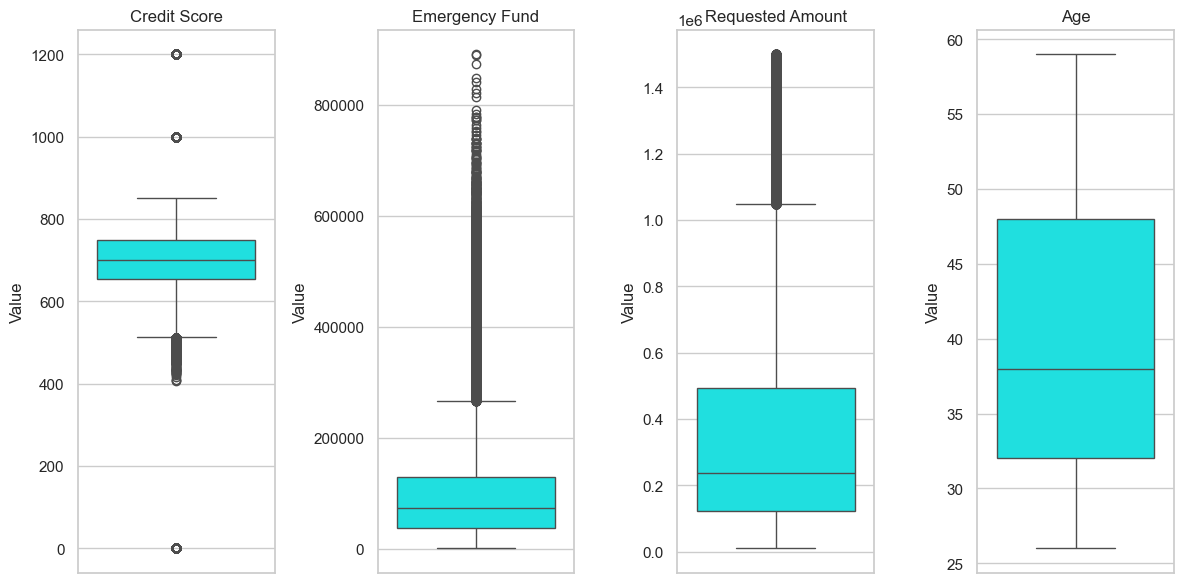

In [124]:
# Set style
sns.set(style="whitegrid")

# Create figure and subplots
plt.figure(figsize=(12, 6))

# List of columns to plot
cols = ['credit_score', 'emergency_fund', 'requested_amount', 'age']

# Plot each boxplot
for i, col in enumerate(cols, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df[col], color='cyan')
    plt.title(f'{col.replace("_", " ").title()}')
    plt.ylabel('Value')

plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart? Insights? Will the insights have a positive business impact? 

I chose a box plot to visualie the spread of the data as well as the outliers (grey circles). We can see Emergency Fund as many outliers so does Requested Amount. We can see most people have a credit score of 700 which is decent/good. Most people don't have a lot of money in their emergency fund as the median is less than 100,000. Most people are around 38 years old. This helps us understand our data more as well as the customer base. 

#### Chart - 5-6

In [125]:
# Standardize gender values
df['gender'] = df['gender'].str.strip().str.upper()

# Map common variants to 'Male' or 'Female'
df['gender'] = df['gender'].replace({
    'M': 'MALE',
    'F': 'FEMALE'
})

# Convert back to title case for clean display
df['gender'] = df['gender'].str.title()


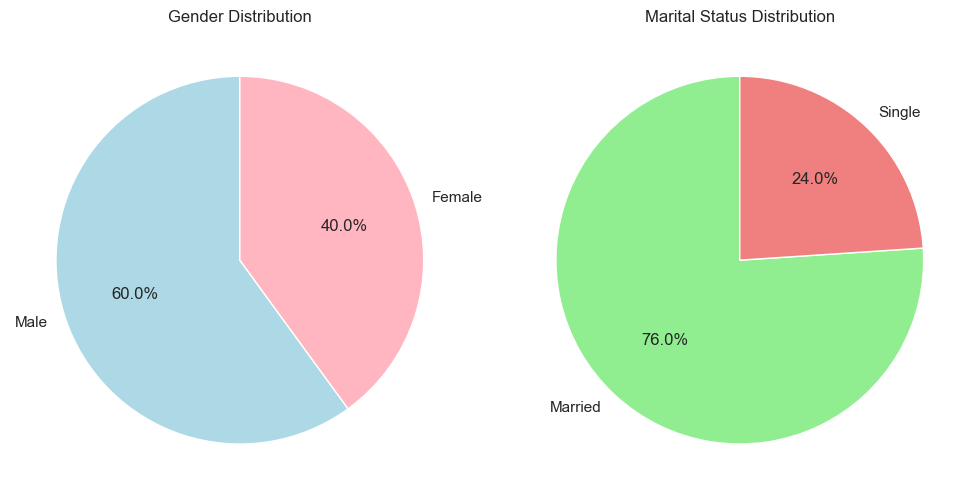

In [126]:

plt.figure(figsize=(10, 5))

# --- Pie chart 1: Gender distribution ---
plt.subplot(1, 2, 1)
gender_counts = df['gender'].value_counts()
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['lightblue', 'lightpink']
)
plt.title('Gender Distribution')

# --- Pie chart 2: Marital Status distribution ---
plt.subplot(1, 2, 2)
marital_counts = df['marital_status'].value_counts()
plt.pie(
    marital_counts,
    labels=marital_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['lightgreen', 'lightcoral', 'gold']
)
plt.title('Marital Status Distribution')

# Show both charts
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart? Insights? Will the insights have a positive business impact? 

I chose piechart to further visualise the customers who are asking for EMI loans. Most are Married and most are men. Further analysis would need to be done to look at whether this has a positive business impact. 

#### Chart - 7-8

In [127]:
df['emi_scenario'].value_counts()

emi_scenario
Home Appliances EMI        80988
Personal Loan EMI          80980
E-commerce Shopping EMI    80948
Education EMI              80942
Vehicle EMI                80942
Name: count, dtype: int64

C:\Users\Admin\AppData\Local\Temp\ipykernel_2352\807323549.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='employment_type', palette='Blues')
C:\Users\Admin\AppData\Local\Temp\ipykernel_2352\807323549.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='emi_scenario', palette='Greens')


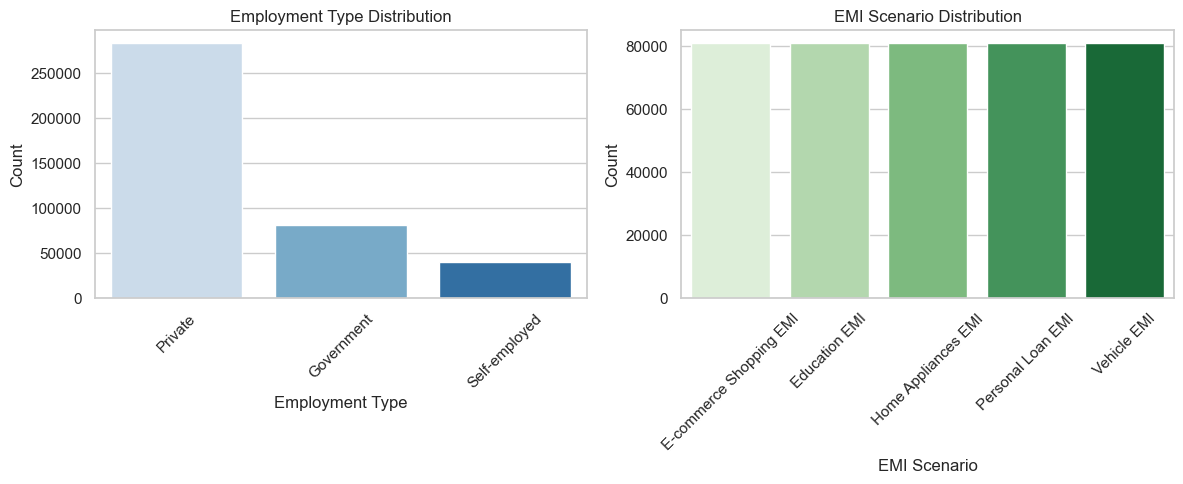

In [128]:

sns.set(style="whitegrid")

# Set up the figure
plt.figure(figsize=(12, 5))

# --- Bar chart 1: Employment Type ---
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='employment_type', palette='Blues')
plt.title('Employment Type Distribution')
plt.xlabel('Employment Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

# --- Bar chart 2: EMI Scenario ---
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='emi_scenario', palette='Greens')
plt.title('EMI Scenario Distribution')
plt.xlabel('EMI Scenario')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Adjust layout
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart? Insights? Will the insights have a positive business impact? 

This is to further visualise the data and customer base. We can see most people are privately employed. Furthermore we can see that the EMI scenarios are equally distributed with around 8000 counts for each feature. 

#### Chart - 9

C:\Users\Admin\AppData\Local\Temp\ipykernel_2352\3778789228.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=salary_category, palette='cool')


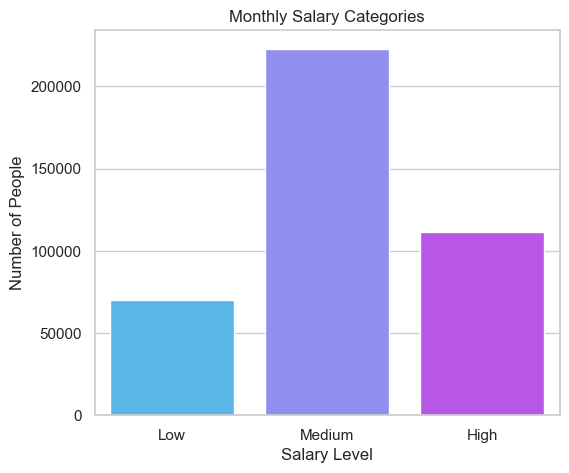

In [129]:
# Get max salary
max_salary = df['monthly_salary'].max()

# Ensure bins are strictly increasing
salary_bins = sorted([0, 30000, 70000, max_salary])
salary_labels = ['Low', 'Medium', 'High']

# Create temporary category
salary_category = pd.cut(df['monthly_salary'], bins=salary_bins, labels=salary_labels, include_lowest=True)

# Plot bar chart
plt.figure(figsize=(6, 5))
sns.countplot(x=salary_category, palette='cool')

plt.title('Monthly Salary Categories')
plt.xlabel('Salary Level')
plt.ylabel('Number of People')
plt.show()


##### 1. Why did you pick the specific chart? Insights? Will the insights have a positive business impact? 

I picked this chart to visualise the Salary levels. Here we can see most people have a Medium salary and the 2nd most popular category is those with a high salary. This helps us understand the customer base further. 

#### Chart - 10-12: Credit Score vs features 

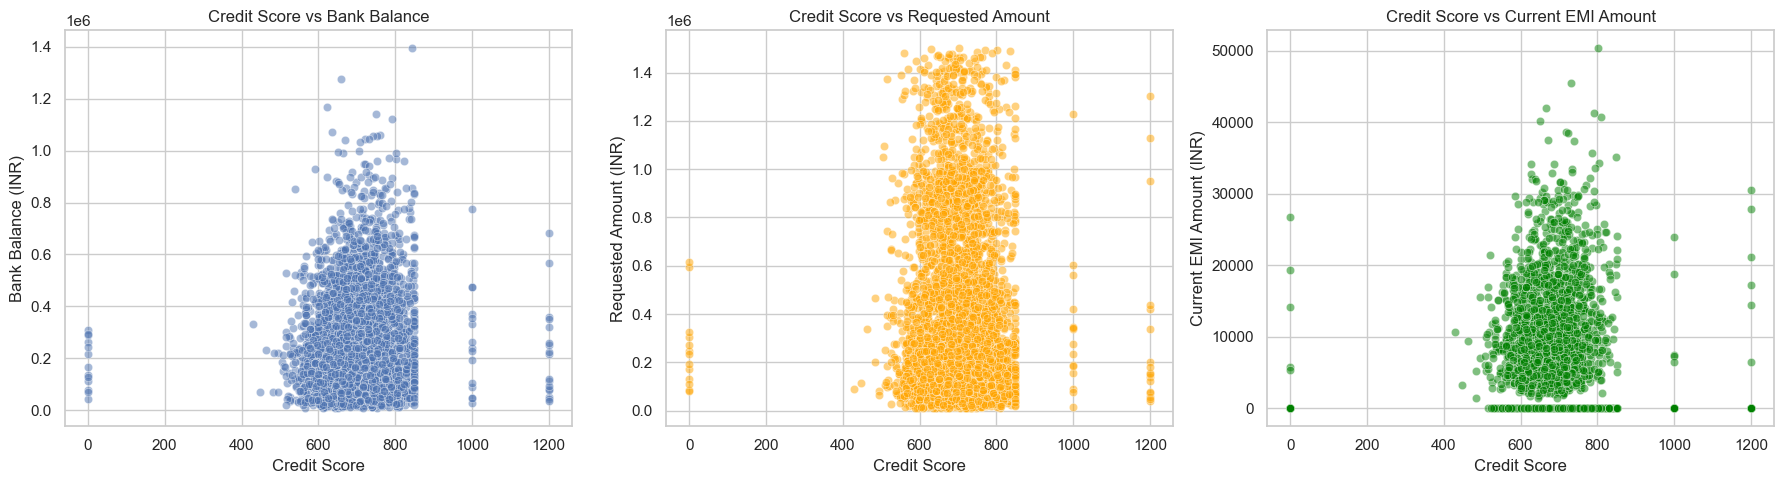

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set(style="whitegrid")

# Take a random sample of 5000 rows for plotting
sample_df = df.sample(n=5000, random_state=42)

plt.figure(figsize=(18, 5))

# 1️Credit Score vs Bank Balance
plt.subplot(1, 3, 1)
sns.scatterplot(data=sample_df, x='credit_score', y='bank_balance', alpha=0.5)
plt.title('Credit Score vs Bank Balance')
plt.xlabel('Credit Score')
plt.ylabel('Bank Balance (INR)')

# Credit Score vs Requested Amount
plt.subplot(1, 3, 2)
sns.scatterplot(data=sample_df, x='credit_score', y='requested_amount', alpha=0.5, color='orange')
plt.title('Credit Score vs Requested Amount')
plt.xlabel('Credit Score')
plt.ylabel('Requested Amount (INR)')

# Credit Score vs Current EMI Amount
plt.subplot(1, 3, 3)
sns.scatterplot(data=sample_df, x='credit_score', y='current_emi_amount', alpha=0.5, color='green')
plt.title('Credit Score vs Current EMI Amount')
plt.xlabel('Credit Score')
plt.ylabel('Current EMI Amount (INR)')

plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart? Insights? Will the insights have a positive business impact? 

I picked these charts to see if there was a correlation between credit scores and various features. Here we can see there is no immmediate correlation. This helps us understand the customer further. 

#### Chart - 13

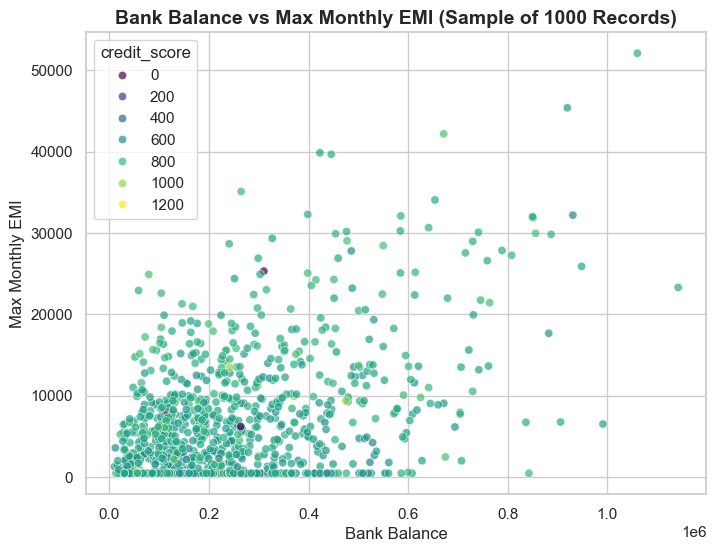

In [131]:
df_sample = df.sample(n=1000, random_state=42)

# Set a clean style
sns.set(style="whitegrid")

# Create the scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_sample,
    x='bank_balance',
    y='max_monthly_emi',
    hue='credit_score',          
    palette='viridis',
    alpha=0.7
)

# Add titles and labels
plt.title('Bank Balance vs Max Monthly EMI (Sample of 1000 Records)', fontsize=14, fontweight='bold')
plt.xlabel('Bank Balance', fontsize=12)
plt.ylabel('Max Monthly EMI', fontsize=12)

# Show the plot
plt.show()

##### 1. Why did you pick the specific chart? Insights? Will the insights have a positive business impact? 

I chose this scatter plot to visualise whether there was a relationship between how much money someone had in their bank account and their Max MONTHLY EMI. Again we can see there is no immediate apparent relationship. We can see some people with a low credit score (shown in purple) have high monthly EMI so more analysis could be done on these customers as they may be more risky. 

#### Chart - 14

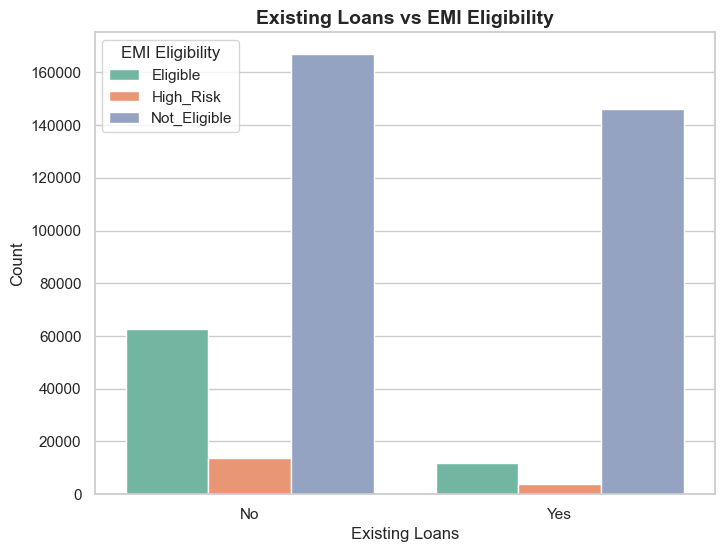

In [132]:
# Chart - 7 visualization code
sns.set(style="whitegrid")

# Create a clustered bar chart
plt.figure(figsize=(8, 6))
sns.countplot(
    data=df,
    x='existing_loans',
    hue='emi_eligibility',
    palette='Set2'
)

# Add labels and title
plt.title('Existing Loans vs EMI Eligibility', fontsize=14, fontweight='bold')
plt.xlabel('Existing Loans', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='EMI Eligibility')

# Show the plot
plt.show()

##### 1. Why did you pick the specific chart? Insights? Will the insights have a positive business impact? 

I chose this cluster chart to see how many customers are high risk , eligible and not eligible. We can see most people are not eligible for EMI loans. We can also see that most people who already have loans are not eligible for EMI, more people without existing loans are eligible for EMI. More analysis should be done to make sure people who are eligible for EMI are not high risk. 

#### Chart - 15 - Correlation Heatmap

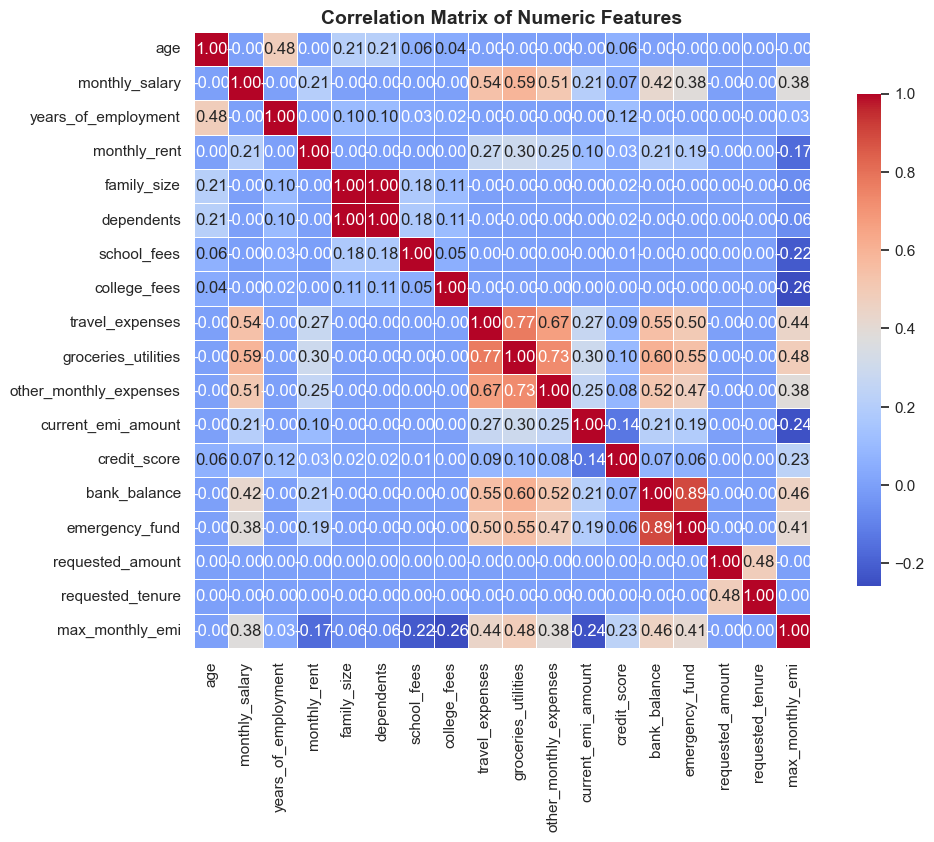

In [133]:
corr = df.corr(numeric_only=True)

# Set up the matplotlib figure
plt.figure(figsize=(12, 8))

# Create the heatmap
sns.heatmap(
    corr,
    annot=True,           # Display correlation coefficients
    fmt=".2f",            # Format to 2 decimal places
    cmap="coolwarm",      # Color palette
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

# Add title
plt.title('Correlation Matrix of Numeric Features', fontsize=14, fontweight='bold')

# Show the plot
plt.show()

##### 1. Why did you pick the specific chart? Insights? Will the insights have a positive business impact? 

I chose this correlation heatmap to visualise the corrlelations between different features in a comprehensive way: we can see there a high correlation between groceries_utilities and travel_expenses. Also there is a high correlation between bank_balance and emergency_fund which makes sense as often customers who have more money will also have more money available to spare and save for an emergency. 

## ***6. Feature Engineering & Data Pre-processing***

### 1. Making sure everything is the correct data type 

In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype   
---  ------                  --------------   -----   
 0   age                     404800 non-null  float64 
 1   gender                  404800 non-null  object  
 2   marital_status          404800 non-null  object  
 3   education               404800 non-null  object  
 4   monthly_salary          404800 non-null  float64 
 5   employment_type         404800 non-null  object  
 6   years_of_employment     404800 non-null  float64 
 7   company_type            404800 non-null  object  
 8   house_type              404800 non-null  object  
 9   monthly_rent            404800 non-null  float64 
 10  family_size             404800 non-null  int64   
 11  dependents              404800 non-null  int64   
 12  school_fees             404800 non-null  float64 
 13  college_fees            404800 non-null  float64 
 14  trav

In [135]:
# Convert nullable numeric types to regular float64
for col in df.select_dtypes(include=['Int64', 'Float64']).columns:
    df[col] = df[col].astype('float64')

# Convert string columns to standard object dtype (optional but safer for legacy libs)
for col in df.select_dtypes(include=['string']).columns:
    df[col] = df[col].astype('object')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype   
---  ------                  --------------   -----   
 0   age                     404800 non-null  float64 
 1   gender                  404800 non-null  object  
 2   marital_status          404800 non-null  object  
 3   education               404800 non-null  object  
 4   monthly_salary          404800 non-null  float64 
 5   employment_type         404800 non-null  object  
 6   years_of_employment     404800 non-null  float64 
 7   company_type            404800 non-null  object  
 8   house_type              404800 non-null  object  
 9   monthly_rent            404800 non-null  float64 
 10  family_size             404800 non-null  float64 
 11  dependents              404800 non-null  float64 
 12  school_fees             404800 non-null  float64 
 13  college_fees            404800 non-null  float64 
 14  trav

### 2. Handling Outliers

In [136]:
numeric_cols = df.select_dtypes(include=['number']).columns

In [137]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns

# Handle outliers using IQR method (cap them)
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap (winsorize) outliers
    df[col] = np.where(df[col] < lower_bound, lower_bound,
                       np.where(df[col] > upper_bound, upper_bound, df[col]))


##### What all outlier treatment techniques have you used and why did you use those techniques?

Here i used IQR outlier method to remove outliers so the ML model peforms better in the end. 

### 3. Categorical Encoding

#### What all categorical encoding techniques have you used & why did you use those techniques?

I'm going to do categorical encoding after splitting my data to avoid data leakage. 

### 6. Data Scaling

In [138]:
# Transform Your data

In [139]:
# Scaling your data

##### Which method have you used to scale you data and why?

### 8. Feature engineering

In [140]:
df['debt_to_income'] = df['current_emi_amount'] / df['monthly_salary']
df['expenses_to_income'] = (
    df[['monthly_rent', 'school_fees', 'college_fees', 'travel_expenses',
        'groceries_utilities', 'other_monthly_expenses']].sum(axis=1)
    / df['monthly_salary']
)



In [141]:
df['employment_stability'] = df['years_of_employment'] / df['age']
df['high_risk'] = ((df['credit_score'] < 600) | (df['debt_to_income'] > 0.4)).astype(int)


In [142]:
df.columns

Index(['age', 'gender', 'marital_status', 'education', 'monthly_salary',
       'employment_type', 'years_of_employment', 'company_type', 'house_type',
       'monthly_rent', 'family_size', 'dependents', 'school_fees',
       'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
       'requested_amount', 'requested_tenure', 'emi_eligibility',
       'max_monthly_emi', 'debt_to_income', 'expenses_to_income',
       'employment_stability', 'high_risk'],
      dtype='object')

In [143]:
df.head()

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi,debt_to_income,expenses_to_income,employment_stability,high_risk
0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,70200.0,Personal Loan EMI,850000.0,15.0,Not_Eligible,500.0,0.242131,0.725182,0.023684,0
1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,26900.0,E-commerce Shopping EMI,128000.0,19.0,Not_Eligible,700.0,0.190698,0.716279,0.184211,0
2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,267600.0,Education EMI,306000.0,16.0,Eligible,23730.0,0.000000,0.413473,0.152632,0
3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,178100.0,Vehicle EMI,304000.0,77.5,Eligible,16170.0,0.000000,0.559880,0.037931,0
4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,28200.0,Home Appliances EMI,252000.0,7.0,Not_Eligible,500.0,0.000000,0.934555,0.070833,0


In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype   
---  ------                  --------------   -----   
 0   age                     404800 non-null  float64 
 1   gender                  404800 non-null  object  
 2   marital_status          404800 non-null  object  
 3   education               404800 non-null  object  
 4   monthly_salary          404800 non-null  float64 
 5   employment_type         404800 non-null  object  
 6   years_of_employment     404800 non-null  float64 
 7   company_type            404800 non-null  object  
 8   house_type              404800 non-null  object  
 9   monthly_rent            404800 non-null  float64 
 10  family_size             404800 non-null  float64 
 11  dependents              404800 non-null  float64 
 12  school_fees             404800 non-null  float64 
 13  college_fees            404800 non-null  float64 
 14  trav

In [146]:
df.to_csv("Processed_data.csv", index=False)  # CSV format